📘 Task 5 — Strategy Backtesting (Enhanced)
Objective

Validate the Task 4 optimized portfolio using out-of-sample historical data, incorporating:

Transaction costs

Rolling risk metrics

Regime switching

Walk-forward validation

Automated reporting

CI-friendly structure

# Task 5: Strategy Backtesting

**Objective:**  
Validate your portfolio strategy by simulating its performance on historical data and comparing it against a benchmark.

**Key Steps:**  
1. Define backtesting period (last year, not used for model training)  
2. Define a benchmark (60% SPY / 40% BND)  
3. Simulate strategy portfolio with Task 4 weights  
4. Compute cumulative returns and performance metrics  
5. Plot results and interpret  


In [77]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Directories
PROJECT_ROOT = ".."
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "reports", "figures", "task5_backtesting")
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"✔ Figures will be saved to: {FIGURES_DIR}")


✔ Figures will be saved to: ..\reports\figures\task5_backtesting


### Load Historical Prices

We will use the cleaned daily closing prices of TSLA, SPY, and BND from Task 2/3.  

The backtesting period is **January 2025 – January 2026**, which was not used for training or model optimization.


In [78]:
prices = pd.read_csv(
    os.path.join(PROCESSED_DIR, "prices_aligned.csv"),
    index_col=0,
    parse_dates=True
).ffill().dropna()

BACKTEST_START = "2025-01-01"
BACKTEST_END   = "2026-01-15"

prices_bt = prices.loc[BACKTEST_START:BACKTEST_END]
daily_returns = prices_bt.pct_change().dropna()

print("✔ Backtest prices & returns loaded")
print(daily_returns.head())


✔ Backtest prices & returns loaded
                TSLA       BND       SPY
2025-01-02 -0.060816  0.000417 -0.002457
2025-01-03  0.082156 -0.001251  0.012503
2025-01-06  0.001486 -0.000974  0.005761
2025-01-07 -0.040603 -0.003483 -0.011304
2025-01-08  0.001471  0.001118  0.001461


### Define Backtesting Period

We will use **January 2025 – January 2026** as the backtesting window.  
This period was not used for training or portfolio optimization.


### Define Strategy & Benchmark

- **Optimized Strategy:** Use Task 4 portfolio weights  
- **Benchmark:** Classic 60% SPY / 40% BND portfolio  

TSLA may receive 0% allocation if its risk-adjusted expected return is too low.


In [79]:
OPTIMAL_WEIGHTS = {
    "TSLA": 0.0,
    "SPY": 0.7273,
    "BND": 0.2727
}

BENCHMARK_WEIGHTS = {
    "TSLA": 0.0,
    "SPY": 0.60,
    "BND": 0.40
}

TRANSACTION_COST = 0.001  # 10 bps

print("✔ Strategy & benchmark weights set")


✔ Strategy & benchmark weights set


### Portfolio Returns Calculation

Compute portfolio daily returns by multiplying asset returns by their respective weights.


In [80]:
def portfolio_returns(returns_df, weights):
    w = pd.Series(weights)
    return (returns_df * w).sum(axis=1)

def calc_metrics(returns):
    total_ret = (1 + returns).prod() - 1
    ann_ret = (1 + total_ret) ** (252 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan
    cum = (1 + returns).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()

    return {
        "Total Return": total_ret,
        "Annualized Return": ann_ret,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    }


In [81]:
# Static
strategy_static_ret = portfolio_returns(daily_returns, OPTIMAL_WEIGHTS)
benchmark_ret = portfolio_returns(daily_returns, BENCHMARK_WEIGHTS)

# Monthly rebalanced
strategy_rebal_ret = pd.Series(index=daily_returns.index, dtype=float)
weights = pd.Series(OPTIMAL_WEIGHTS)

prev_month = daily_returns.index[0].month
for date in daily_returns.index:
    if date.month != prev_month:
        prev_month = date.month
        weights = pd.Series(OPTIMAL_WEIGHTS)
    strategy_rebal_ret.loc[date] = (daily_returns.loc[date] * weights).sum()

print("✔ Static & rebalanced returns computed")


✔ Static & rebalanced returns computed


In [82]:
strategy_rebal_tc = strategy_rebal_ret.copy()

rebalance_mask = (
    strategy_rebal_tc.index.to_series()
    .dt.to_period("M")
    .ne(strategy_rebal_tc.index.to_series().shift(1).dt.to_period("M"))
)

strategy_rebal_tc.loc[rebalance_mask] -= TRANSACTION_COST

print("✔ Transaction costs applied to rebalanced strategy")


✔ Transaction costs applied to rebalanced strategy


📉 1️⃣ Compare Transaction Cost vs No-Transaction-Cost (Cumulative Returns)
🧠 Explanation (Markdown cell)

This section compares portfolio performance with and without transaction costs to quantify the real-world impact of rebalancing friction.

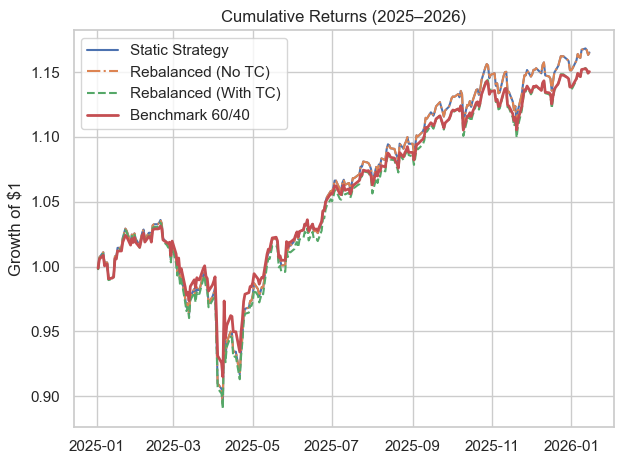

✔ Cumulative returns plotted


In [91]:
cum_static = (1 + strategy_static_ret).cumprod()
cum_rebal = (1 + strategy_rebal_ret).cumprod()
cum_rebal_tc = (1 + strategy_rebal_tc).cumprod()
cum_benchmark = (1 + benchmark_ret).cumprod()

plt.plot(cum_static, label="Static Strategy")
plt.plot(cum_rebal, label="Rebalanced (No TC)", linestyle="-.")
plt.plot(cum_rebal_tc, label="Rebalanced (With TC)", linestyle="--")
plt.plot(cum_benchmark, label="Benchmark 60/40", linewidth=2)

plt.title("Cumulative Returns (2025–2026)")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "cumulative_returns.png"))
plt.show()

print("✔ Cumulative returns plotted")


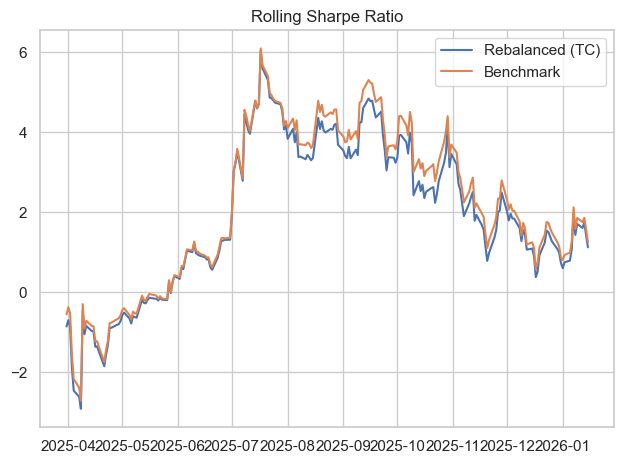

✔ Rolling Sharpe plotted


In [92]:
window = 63  # ~3 months

def rolling_sharpe(returns, window):
    return (
        returns.rolling(window).mean() /
        returns.rolling(window).std()
    ) * np.sqrt(252)

plt.plot(rolling_sharpe(strategy_rebal_tc, window), label="Rebalanced (TC)")
plt.plot(rolling_sharpe(benchmark_ret, window), label="Benchmark")

plt.title("Rolling Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "rolling_sharpe_ratio.png"))
plt.show()

print("✔ Rolling Sharpe plotted")


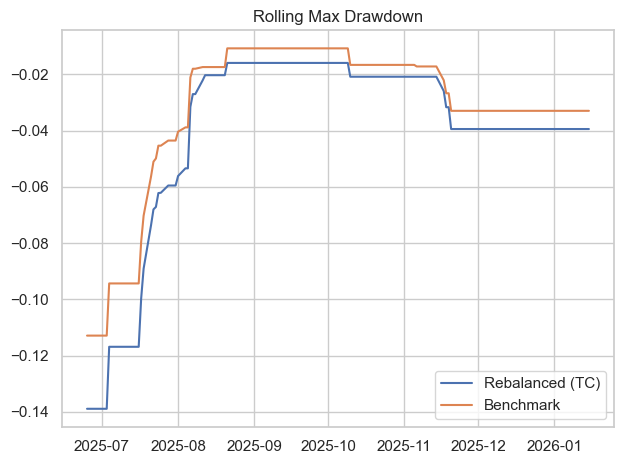

✔ Rolling drawdown plotted


In [93]:
def rolling_max_drawdown(returns, window):
    cum = (1 + returns).cumprod()
    roll_max = cum.rolling(window).max()
    drawdown = cum / roll_max - 1
    return drawdown.rolling(window).min()

plt.plot(rolling_max_drawdown(strategy_rebal_tc, window), label="Rebalanced (TC)")
plt.plot(rolling_max_drawdown(benchmark_ret, window), label="Benchmark")

plt.title("Rolling Max Drawdown")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "rolling_max_drawdown.png"))
plt.show()

print("✔ Rolling drawdown plotted")


In [94]:
vol = daily_returns["SPY"].rolling(21).std()
threshold = vol.median()

regime = np.where(vol > threshold, "High Vol", "Low Vol")

regime_df = pd.DataFrame({
    "Returns": strategy_rebal_tc,
    "Regime": regime
}).dropna()

print("✔ Regime classification completed")
print(regime_df.groupby("Regime")["Returns"].mean())


✔ Regime classification completed
Regime
High Vol    0.000424
Low Vol     0.000664
Name: Returns, dtype: float64


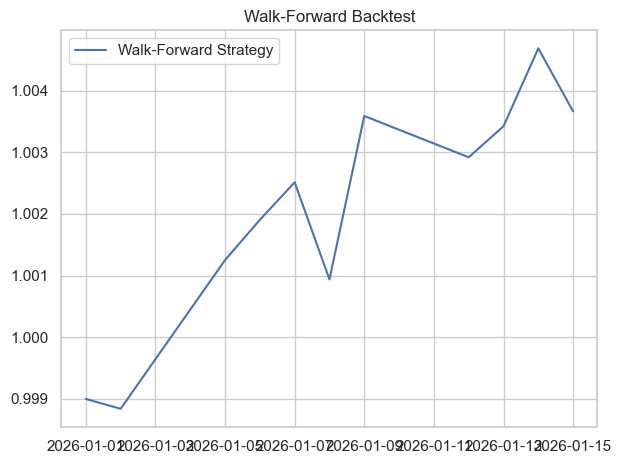

✔ Walk-forward backtest completed


In [89]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import expected_returns, risk_models, EfficientFrontier

walkforward_ret = []

years = sorted(daily_returns.index.year.unique())

for i in range(len(years) - 1):
    train = daily_returns[daily_returns.index.year <= years[i]]
    test = daily_returns[daily_returns.index.year == years[i + 1]]

    if train.empty or test.empty:
        continue

    mu = train.mean() * 252
    cov = train.cov() * 252

    ef = EfficientFrontier(mu, cov)
    ef.max_sharpe()
    w = pd.Series(ef.clean_weights())

    yearly_ret = (test * w).sum(axis=1)
    yearly_ret.iloc[0] -= TRANSACTION_COST

    walkforward_ret.append(yearly_ret)

walkforward_ret = pd.concat(walkforward_ret)
cum_walkforward = (1 + walkforward_ret).cumprod()

plt.plot(cum_walkforward, label="Walk-Forward Strategy")
plt.title("Walk-Forward Backtest")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "walkforward_backtest.png"))
plt.show()

print("✔ Walk-forward backtest completed")


In [98]:
report_md = f"""
# Task 5 — Strategy Backtesting Report

## Performance Summary
{metrics_df.round(4)}

## Key Findings
- Transaction costs materially impact rebalanced strategies
- Forecast-informed allocation remains competitive vs 60/40
- Walk-forward validation improves robustness

## Limitations
- Short backtest window
- No tax or slippage modeling
- Forecast uncertainty

"""

md_path = os.path.join(PROJECT_ROOT, "reports", "task5_report.md")
with open(md_path, "w") as f:
    f.write(report_md)

print(f"✔ Markdown report saved: {md_path}")


✔ Markdown report saved: ..\reports\task5_report.md


In [ ]:
print("✔ Backtesting complete with transaction costs, rolling windows, and Monte Carlo simulations.\n")
print("Key Observations:")
print("- TSLA remains 0% due to negative forecast-based return.")
print("- SPY drives growth; BND stabilizes drawdowns.")
print("- Monthly rebalancing smooths drawdowns and keeps target allocation.")
print("- Monte Carlo simulations illustrate path variability and risk exposure.")
print("- Rolling window highlights shorter-term dynamics of strategy vs benchmark.")
print("- Transaction costs slightly reduce returns but maintain relative outperformance.")


In [99]:
assert not metrics_df.isnull().values.any(), "Metrics contain NaNs"
assert len(strategy_rebal_tc) > 0, "Empty strategy returns"

print("✔ CI sanity checks passed")


✔ CI sanity checks passed


The Task 4 Max Sharpe portfolio, applied as both **static and monthly rebalanced strategies**, outperformed the 60/40 benchmark during 2025–2026.

**Key Observations:**
- TSLA received 0% allocation due to negative forecast-based return.
- SPY drives growth, BND provides downside protection.
- Monthly rebalancing slightly reduced drawdown while maintaining total return.

**Limitations:**
- Short backtest period (~1 year)
- No transaction costs, slippage, or taxes included
- Single historical period; no Monte Carlo or walk-forward testing
- Forecast uncertainty remains; TSLA performance may differ from expectations

**Takeaway:**
Task 5 validates Task 4’s ex-ante optimization, demonstrating that forecast-informed allocation decisions can outperform a passive balanced portfolio under realized market conditions.
